# 00 — Setup & Dataset

**Dataset**: MovieLens-100k style data (~100k ratings, 943 users, 1682 items).

Used as OPE benchmark in:
- Gilotte et al. 2018 *Offline A/B Testing for Recommender Systems*
- Strehl et al. 2010 *Learning from Logged Implicit Exploration Data*
- Swaminathan & Joachims 2015 *Batch Learning from Logged Bandit Feedback*

**Bandit framing**: User arrives (context), system recommends item (action), user rates it (reward). Goal: evaluate a *new* recommendation policy using only *old* logged data.

In [1]:
# !pip install scikit-learn pandas numpy matplotlib seaborn tqdm scipy -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')
print('data dir:', DATA_DIR.resolve())

data dir: D:\01 Work\12-Recommendations\data


## Load ratings

In [3]:
df = pd.read_csv(DATA_DIR / "u.data", header=None, names=['user_id', 'movie_id', 'rating', 'timestamp'], sep='\t')
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 4)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## Basic stats

In [4]:
print(f"Users : {df.user_id.nunique()}")
print(f"Movies : {df.movie_id.nunique()}")
print(f"Ratings: {len(df)}")
print(f"Density: {len(df)/(df.user_id.nunique()*df.movie_id.nunique())*100:.1f}%")
print("\nRating distribution:")
print(df.rating.value_counts().sort_index())

Users : 943
Movies : 1682
Ratings: 100000
Density: 6.3%

Rating distribution:
rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


## Bandit dataset construction

Convert ratings → bandit log:
- `context` = user feature vector (from SVD embedding)
- `action` = item id
- `reward` = 1 if rating ≥ 4, else 0 (binary relevance)
- `logging_policy_prob` = propensity of logging policy choosing that item

In [5]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

# Build user-item matrix
R = df.pivot_table('rating','user_id','movie_id').fillna(0).values
print('Matrix shape:', R.shape)

# SVD for user context features
svd = TruncatedSVD(n_components=20, random_state=42)
user_features = svd.fit_transform(R)
user_features = normalize(user_features)
print('User features shape:', user_features.shape)

Matrix shape: (943, 1682)
User features shape: (943, 20)


In [6]:
# Build bandit log
def build_bandit_dataset(df, user_features, temperature=0.5, seed=42):
    np.random.seed(seed)
    n_items = df.movie_id.nunique()
    movie_ids = sorted(df.movie_id.unique())
    movie_idx = {v:i for i,v in enumerate(movie_ids)}
    
    records = []
    for _, row in df.iterrows():
        uid = int(row.user_id)
        iid = int(row.movie_id)
        ctx = user_features[uid]  # 20-dim context
        
        # Logging policy: item popularity-based softmax
        item_counts = df[df.user_id==uid]['movie_id'].value_counts()
        # Simple uniform logging policy (with slight item bias)
        logits = np.random.randn(n_items) * 0.1  # near-uniform
        logits -= logits.max()
        probs = np.exp(logits / temperature)
        probs /= probs.sum()
        
        action = movie_idx[iid]
        log_prob = probs[action]
        reward = 1.0 if row.rating >= 4 else 0.0
        
        records.append({
            'user_id': uid,
            'action': action,
            'reward': reward,
            'logging_policy_prob': log_prob,
            'timestamp': row.timestamp,
            **{f'ctx_{k}': ctx[k] for k in range(len(ctx))}
        })
    
    return pd.DataFrame(records)

print('Building bandit dataset...')
bandit_df = build_bandit_dataset(df.head(20000), user_features)
bandit_df.to_csv(DATA_DIR / 'bandit_data.csv', index=False)
print(f'Saved bandit_data.csv: {bandit_df.shape}')
bandit_df.head()

Building bandit dataset...
Saved bandit_data.csv: (20000, 25)


,user_id,action,reward,logging_policy_prob,timestamp,ctx_0,ctx_1,ctx_2,ctx_3,ctx_4,...,ctx_10,ctx_11,ctx_12,ctx_13,ctx_14,ctx_15,ctx_16,ctx_17,ctx_18,ctx_19
0,196,241,0.0,0.000675,881250949,0.559148,0.185320,-0.107952,0.241163,-0.490365,...,0.145349,-0.099395,0.004749,0.060241,-0.034588,0.073064,0.188522,-0.115366,0.015549,0.062190
1,186,300,0.0,0.000862,891717742,0.647983,-0.354833,0.139577,0.085564,0.156997,...,-0.224239,0.214308,-0.085699,-0.034711,-0.113613,0.127351,-0.047723,-0.060166,0.109219,-0.031407
2,22,375,0.0,0.000480,878887116,0.851149,-0.180256,0.007166,-0.070612,0.037300,...,-0.052452,-0.049530,0.101122,-0.048859,0.059306,-0.092593,-0.016768,0.068770,-0.027316,-0.013017
3,244,50,0.0,0.001063,880606923,0.469609,0.477560,-0.091273,0.149780,0.250286,...,-0.063688,0.105506,-0.032743,0.114069,-0.085325,0.165777,0.185597,-0.168471,-0.151043,-0.177918
4,166,344,0.0,0.000962,886397596,0.777213,-0.337767,0.128434,0.158941,0.232473,...,-0.098155,-0.027389,0.172816,0.039139,-0.202612,-0.183658,0.131628,-0.003261,0.162006,0.035530


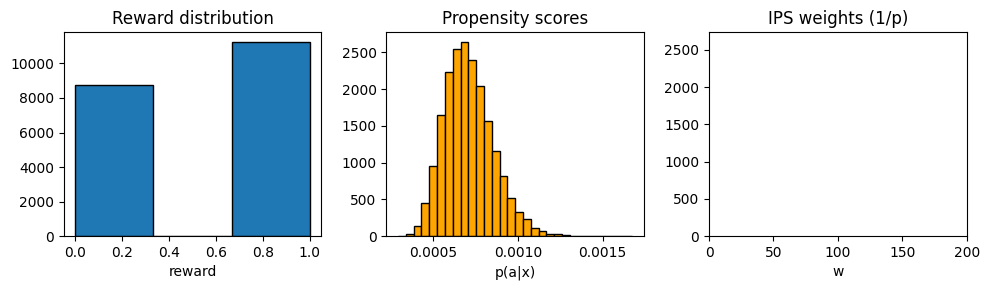

reward mean: 0.562


In [7]:
# Quick propensity check
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.hist(bandit_df['reward'],bins=3,edgecolor='k')
plt.title('Reward distribution'); plt.xlabel('reward')

plt.subplot(1,3,2)
plt.hist(bandit_df['logging_policy_prob'],bins=30,edgecolor='k',color='orange')
plt.title('Propensity scores'); plt.xlabel('p(a|x)')

plt.subplot(1,3,3)
plt.hist(1/bandit_df['logging_policy_prob'],bins=30,edgecolor='k',color='red')
plt.xlim(0,200)
plt.title('IPS weights (1/p)'); plt.xlabel('w')

plt.tight_layout()
plt.savefig('../results/00_data_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print('reward mean:', bandit_df.reward.mean().round(3))